### Modelo de dados: livro

A classe `Livro` representa cada obra do acervo. O construtor guarda título, autor, gênero e estoque; o método `__str__` define uma forma legível de apresentar um objeto Livro.

In [ ]:
# ==============================================================================
# SISTEMA DE GERENCIAMENTO DE BIBLIOTECA
# Disciplina: Linguagem de Programação
# Autor: LUÍS HENRIQUE DE SOUZA
# ==============================================================================

import matplotlib.pyplot as plt

# --- DEFINIÇÃO DA CLASSE LIVRO ---
class Livro:

  def __init__(self, titulo, autor, genero, estoque):
    # Atributos básicos da obra
    self.titulo = titulo
    self.autor = autor
    self.genero = genero
    self.estoque = estoque

  # Definição de como o livro será exibido ao ser printado na tela
  def __str__(self):
    return (f"Título: {self.titulo}\nAutor: {self.autor}\ngenero: {self.genero}\nEstoque: {self.estoque}")

### Estruturas para armazenar o acervo

As listas mantêm os livros cadastrados e os gêneros encontrados. Elas servem como armazenamento em memória durante a execução do programa.

In [ ]:
# --- CRIAR A LISTA DE LIVROS ---
acervo = []
generos = []

### Operações de gerenciamento

As funções deste bloco cadastram, listam, buscam e removem livros. Observe como a busca percorre o acervo e como o estoque determina se uma obra está disponível.

In [33]:
# --- FUNÇÕES DE GERENCIAMENTO ---

# Cadastrar novos Livros
def cadastro_livro(titulo, autor, genero, estoque):

  # procuca um livro pelo título para ver se já está cadastrado
  for livro in acervo:
    if livro.titulo == titulo:
      print(f"O livro {titulo} já está cadastrado no sistema!")
      return

  # instancia um novo livro e o adiciona à lista do acervo
  novo_livro = Livro(titulo, autor, genero, estoque)
  acervo.append(novo_livro)

  # verifica se o genero ainda não está na lista para não gerar duplicações
  if genero not in generos:
    generos.append(genero)

  print(f"O livro {titulo} foi cadastrado com sucesso!")


# Listar livros cadastrados
def listar_livros():
  # verifica se existe o titulo no acervo
  if not acervo:
    print("Nenhum livro cadastrado no momento.")
    return

  print("\n--- Acervo de Livros da Biblioteca ---")
  for livro in acervo:
    print(f"\n{livro}")


# Buscar um Livro
def buscar_livro(titulo_busca):
  livro_encontrado = None

  # Percorre a lista procurando pelo título
  for livro in acervo:
    if livro.titulo.lower() == titulo_busca.lower():
      livro_encontrado = livro
      break

  # Verifica o resultado
  if livro_encontrado:
    if livro_encontrado.estoque > 0:
      print(
          f" O livro '{livro_encontrado.titulo}' está disponível!"
          f" ({livro_encontrado.estoque} unidades)"
      )
    else:
      print(
          f" O livro '{livro_encontrado.titulo}' pertence ao acervo, mas está"
          " indisponível no momento (Estoque: 0)."
      )
    return livro_encontrado
  else:
    print(" Título não encontrado no acervo.")
    return None


# Remover Livro
def remover_livro(titulo):
  for livro in acervo:
    if livro.titulo == titulo:
      acervo.remove(livro)
      print(f"O livro {titulo} foi removido com sucesso!")
      return

  print(f"O livro {titulo} não está no nosso acervo.")


### Visualização do acervo

Esta função soma os exemplares por gênero e monta um gráfico de barras com Matplotlib. Se o acervo estiver vazio, encerra a operação com uma mensagem.

In [34]:
# --- GERAR GRÁFICO COM MATPLOTLIB ---
def gerar_grafico_por_genero():

  # Agrupa as quantidades de livros por gênero e gera um gráfico de barras.
  if not acervo:
    print("\nImpossível gerar gráfico: acervo vazio.")
    return

  # Dicionário para contabilizar total de exemplares por gênero
  generos_qtd = {}
  for livro in acervo:
    genero = livro.genero
    generos_qtd[genero] = generos_qtd.get(genero, 0) + livro.estoque

  # Separação dos dados para o gráfico
  categorias = list(generos_qtd.keys())
  quantidades = list(generos_qtd.values())

  # Configuração e exibição do gráfico com Matplotlib
  plt.figure(figsize=(8, 5))
  plt.bar(categorias, quantidades, alpha=0.6, color="#580F41", edgecolor="black")
  plt.title("Quantidade de Livros por Gênero")
  plt.xlabel("Gêneros")
  plt.ylabel("Quantidade Total de Exemplares")
  plt.grid(axis="y", linestyle="--", alpha=0.7)
  plt.show()

### Demonstração do sistema

Este bloco cadastra dados de exemplo e exercita as operações de listagem, busca, remoção e geração do gráfico. Altere os exemplos para observar como o estado do acervo afeta os resultados.

--- CADASTRANDO LIVROS DE TESTE ---
O livro Dom Casmurro já está cadastrado no sistema!
O livro O Hobbit já está cadastrado no sistema!
O livro A Revolução dos Bichos já está cadastrado no sistema!
O livro O Alquimista já está cadastrado no sistema!
O livro Duna já está cadastrado no sistema!
O livro Harry Potter foi cadastrado com sucesso!



--- Acervo de Livros da Biblioteca ---

Título: Dom Casmurro
Autor: Machado de Assis
genero: Romance
Estoque: 15

Título: O Hobbit
Autor: J.R.R. Tolkien
genero: Fantasia
Estoque: 10

Título: 1984
Autor: George Orwell
genero: Ficção Científica
Estoque: 8

Título: O Alquimista
Autor: Paulo Coelho
genero: Romance
Estoque: 12

Título: Duna
Autor: Frank Herbert
genero: Ficção Científica
Estoque: 6

Título: A Revolução dos Bichos
Autor: George Orwell
genero: Ficção Científica
Estoque: 8

Título: Harry Potter
Autor: J.K. Rowling
genero: Fantasia
Estoque: 0


 O livro '1984' está disponível! (8 unidades)
 O livro 'Harry Potter' pertence ao acervo, mas es

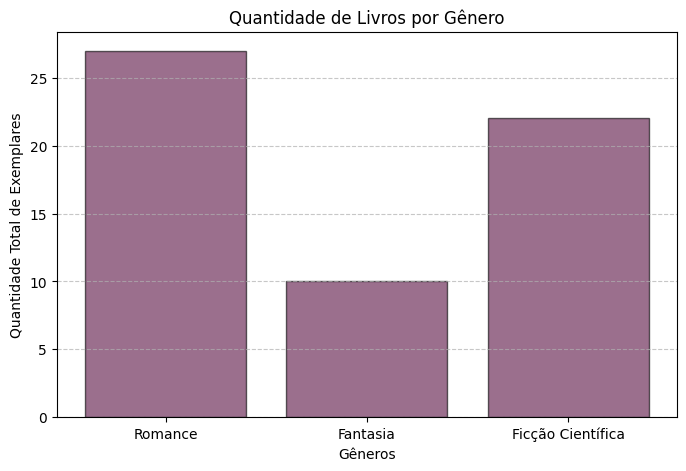

In [35]:
# --- TESTANDO O SISTEMA ---
print("--- CADASTRANDO LIVROS DE TESTE ---")
cadastro_livro("Dom Casmurro", "Machado de Assis", "Romance", 15)
cadastro_livro("O Hobbit", "J.R.R. Tolkien", "Fantasia", 10)
cadastro_livro("A Revolução dos Bichos", "George Orwell", "Ficção Científica", 8)
cadastro_livro("O Alquimista", "Paulo Coelho", "Romance", 12)
cadastro_livro("Duna", "Frank Herbert", "Ficção Científica", 6)
cadastro_livro("Harry Potter", "J.K. Rowling", "Fantasia", 0)

print("\n")
# Listando acervo
listar_livros()

print("\n")
# Testando a busca
buscar_livro("1984")
buscar_livro("Harry Potter")
buscar_livro("Jesse Souza")

print("\n")
# Removendo um livro
remover_livro("Harry Potter")

print("\n")
# Gerando o gráfico visual
gerar_grafico_por_genero()
